<a href="https://colab.research.google.com/github/MartVASS/MaskArchitectureAnomaly_CourseProject/blob/main/notebooks/visualization_semantic_cityscapes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Get GITHUB repo


In [1]:
!git clone https://github.com/MartVASS/MaskArchitectureAnomaly_CourseProject.git
%cd MaskArchitectureAnomaly_CourseProject/eomt

fatal: destination path 'MaskArchitectureAnomaly_CourseProject' already exists and is not an empty directory.
/content/MaskArchitectureAnomaly_CourseProject/eomt


In [2]:
!pip install -r requirements.txt

## Import datasets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Add repo to PYHTONPATH

In [4]:
import sys
import os

sys.path.append(os.getcwd())

### Check if dataset is available


In [5]:
data_path = "/content/drive/MyDrive/Cityscapes"

print(os.listdir(data_path))

['leftImg8bit_trainvaltest.zip', 'gtFine_trainvaltest.zip']


## Preparation code


In [8]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # TODO: change to the GPU you want to use
print(f"device used :{device}")
img_idx = 15  # TODO: change to the index of the image you want to visualize
config_path = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"  # TODO: change to the config file
data_path = "/content/drive/MyDrive/Cityscapes"  # TODO: change to the dataset directory

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

print("Ok STEP 1")

device used :cuda
Ok STEP 1


## Loading validation dataset

In [9]:
print("Starting step 2 : Loading dataset...")

data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

print("OK Step 2")

Starting step 2 : Loading dataset...
OK Step 2


## Loading model

In [10]:
print("Starting step 3 : Loading models...")

warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=data.img_size,
        num_classes=data.num_classes,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

print("Step 3 OK")

Starting step 3 : Loading models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Step 3 OK


## Loading pre-trained weights from hugging face

In [11]:
print("Starting step 4 : Load pre-trained weights from Hugging Face Hub")

name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

print(name)

if name is None:
    warnings.warn("No logger name found in the config. Please specify a model name.")
else:
    try:
        state_dict_path = hf_hub_download(
            repo_id=f"S362484/{name}",
            filename="eomt_cityscapes.bin",
        )

        is_dinov3 = "dinov3" in name

        if is_dinov3:
            model_kwargs["ckpt_path"] = state_dict_path
            model_kwargs["delta_weights"] = True

        model = (
            lit_cls(
                img_size=data.img_size,
                num_classes=data.num_classes,
                network=network,
                **model_kwargs,
            )
            .eval()
            .to(device)
        )

        if not is_dinov3:
            state_dict = torch.load(
            state_dict_path,
            map_location=torch.device(device),
            weights_only=False
            )
            model.load_state_dict(state_dict, strict=False)

    except RepositoryNotFoundError:
        warnings.warn(
            f"Pre-trained model not found for `{name}`. Please load your own checkpoint."
        )

print("Step 4 OK")

Starting step 4 : Load pre-trained weights from Hugging Face Hub
cityscapes_semantic_eomt_base_640


eomt_cityscapes.bin:   0%|          | 0.00/382M [00:00<?, ?B/s]

Step 4 OK


## Semantic inference

Starting step 5 : Semantic inference (pixel-wise classification)


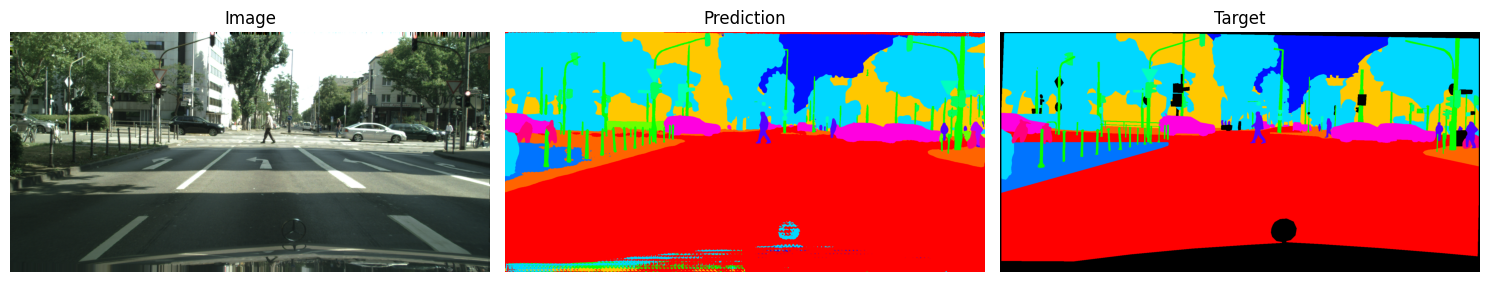

Step 5 OK


In [12]:
print("Starting step 5 : Semantic inference (pixel-wise classification)")

IGNORE_INDEX = 255

def infer_semantic(img, target):
    device_type = "cuda" if device.type == "cuda" else "cpu"

    with torch.no_grad(), autocast(dtype=torch.float16 if device.type == "cuda" else torch.float32,
                               device_type=device_type):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

print("Step 5 OK")